# Lab 6: Sparse Autoencoder on CIFAR-10

In this lab, we implement a **Sparse Autoencoder (SAE)** and train it on the CIFAR-10 dataset. The reference implementation comes from [IParraMartin/Sparse-Autoencoder](https://github.com/IParraMartin/Sparse-Autoencoder) (`sae.py`). We study its architecture, adapt it for CIFAR-10 (changing input dimension from 784 to 3072), train the model, visualize reconstructed images, and experiment with different sparsity penalties.

## 1. Study the Reference SAE Implementation

The original `sae.py` from the repository has the following key components:

| Component | Details |
|---|---|
| **Encoder** | `nn.Linear(in_dims, h_dims)` → `nn.Sigmoid()` — maps input to a higher-dimensional hidden space |
| **Decoder** | `nn.Linear(h_dims, in_dims)` → `nn.Tanh()` — maps hidden features back to input space |
| **Reconstruction Loss** | Mean Squared Error (MSE) between original and reconstructed data |
| **Sparsity Penalty** | KL Divergence — forces average neuron activation to stay close to a target (e.g. 0.05) |
| **Total Loss** | `MSE Loss + λ × KL Divergence Penalty` |
| **Weight Init** | Xavier uniform initialization with zero bias |

The **KL divergence sparsity penalty** compares the actual mean activation of each hidden neuron (`ρ̂`) with the desired target (`ρ`). If a neuron is too active on average, the penalty increases, pushing it to fire less often. This encourages the network to learn sparse, meaningful features.

## 2. Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

## 3. Load and Preprocess CIFAR-10

CIFAR-10 images are 32×32×3 = **3072** values per image. We:
- Convert images to tensors using `transforms.ToTensor()`
- Normalize pixel values to the range [-1, 1] using mean and std of 0.5 per channel
- Flatten the images to a 3072-dim vector during training

In [2]:
# preprocessing pipeline
transform = transforms.Compose([
    transforms.ToTensor(),                # converts PIL image to tensor (values in [0,1])
    transforms.Normalize((0.5, 0.5, 0.5), # normalize each channel: (value - mean) / std
                         (0.5, 0.5, 0.5)) # so pixel values go from [0,1] to [-1,1]
])

# download and load training set
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

# download and load test set
test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    transform=transform,
    download=True
)

batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Image shape: {train_dataset[0][0].shape}")
print(f"Flattened input size: {3 * 32 * 32}")

100%|██████████| 170M/170M [00:54<00:00, 3.14MB/s] 


Extracting ./data\cifar-10-python.tar.gz to ./data
Files already downloaded and verified
Training samples: 50000
Test samples: 10000
Image shape: torch.Size([3, 32, 32])
Flattened input size: 3072


## 4. Define the Sparse Autoencoder

We adapt the reference `sae.py` model for CIFAR-10:
- **Input dimension**: changed from 784 (MNIST) to **3072** (CIFAR-10: 32×32×3)
- **Hidden dimension**: 1024 neurons (a compressed bottleneck)
- **Encoder**: Linear(3072 → 1024) + Sigmoid
- **Decoder**: Linear(1024 → 3072) + Tanh
- **Sparsity**: KL divergence penalty to keep average activations near `sparsity_target`

In [3]:
class SparseAutoencoder(nn.Module):

    def __init__(self, in_dims=3072, h_dims=1024, sparsity_lambda=1e-3, sparsity_target=0.05):
        super().__init__()
        self.sparsity_lambda = sparsity_lambda
        self.sparsity_target = sparsity_target

        # encoder: maps flattened image to hidden features
        self.encoder = nn.Sequential(
            nn.Linear(in_dims, h_dims),
            nn.Sigmoid()
        )

        # decoder: reconstructs image from hidden features
        self.decoder = nn.Sequential(
            nn.Linear(h_dims, in_dims),
            nn.Tanh()
        )

        # xavier initialization (same as reference sae.py)
        nn.init.xavier_uniform_(self.encoder[0].weight)
        nn.init.constant_(self.encoder[0].bias, 0)
        nn.init.xavier_uniform_(self.decoder[0].weight)
        nn.init.constant_(self.decoder[0].bias, 0)

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

    def sparsity_penalty(self, encoded):
        """
        KL divergence sparsity penalty.
        Compares average activation of each hidden neuron (rho_hat)
        with the target sparsity level (rho).
        """
        rho_hat = torch.mean(encoded, dim=0)  # average activation per neuron
        rho = self.sparsity_target

        # clamp to avoid log(0)
        epsilon = 1e-8
        rho_hat = torch.clamp(rho_hat, min=epsilon, max=1 - epsilon)

        # KL divergence
        kl = rho * torch.log(rho / rho_hat) + (1 - rho) * torch.log((1 - rho) / (1 - rho_hat))
        return self.sparsity_lambda * torch.sum(kl)

    def loss_function(self, decoded, original, encoded):
        """Total loss = MSE reconstruction loss + sparsity penalty"""
        mse_loss = F.mse_loss(decoded, original)
        sp_loss = self.sparsity_penalty(encoded)
        return mse_loss + sp_loss

print("Model architecture:")
model = SparseAutoencoder()
print(model)

Model architecture:
SparseAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=3072, out_features=1024, bias=True)
    (1): Sigmoid()
  )
  (decoder): Sequential(
    (0): Linear(in_features=1024, out_features=3072, bias=True)
    (1): Tanh()
  )
)


## 5. Training

In [4]:
# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# hyperparameters
num_epochs = 20
learning_rate = 1e-3

model = SparseAutoencoder(in_dims=3072, h_dims=1024, sparsity_lambda=1e-3, sparsity_target=0.05)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# training loop
train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, _ in train_loader:
        # flatten 32x32x3 images to 3072-dim vectors
        images = images.view(images.size(0), -1).to(device)

        optimizer.zero_grad()
        encoded, decoded = model(images)
        loss = model.loss_function(decoded, images, encoded)
        loss.backward()

        # gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}]  Loss: {avg_loss:.4f}")

print("\nTraining complete!")

Using device: cuda
Epoch [1/20]  Loss: 0.2289
Epoch [2/20]  Loss: 0.1457
Epoch [3/20]  Loss: 0.1175
Epoch [4/20]  Loss: 0.0958
Epoch [5/20]  Loss: 0.0759
Epoch [6/20]  Loss: 0.0598
Epoch [7/20]  Loss: 0.0483
Epoch [8/20]  Loss: 0.0401
Epoch [9/20]  Loss: 0.0339
Epoch [10/20]  Loss: 0.0288
Epoch [11/20]  Loss: 0.0246
Epoch [12/20]  Loss: 0.0214
Epoch [13/20]  Loss: 0.0191
Epoch [14/20]  Loss: 0.0176
Epoch [15/20]  Loss: 0.0164
Epoch [16/20]  Loss: 0.0157
Epoch [17/20]  Loss: 0.0151
Epoch [18/20]  Loss: 0.0145
Epoch [19/20]  Loss: 0.0141
Epoch [20/20]  Loss: 0.0136

Training complete!


### Plot Training Loss

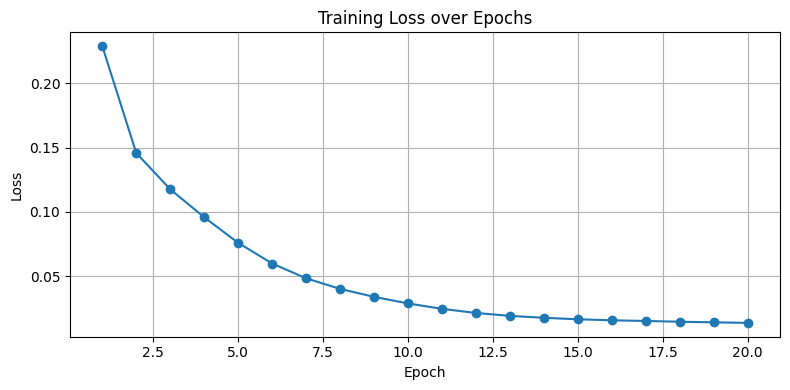

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.tight_layout()
plt.show()

## 6. Evaluate Reconstruction Loss on Test Set

In [6]:
model.eval()
test_loss = 0.0

with torch.no_grad():
    for images, _ in test_loader:
        images = images.view(images.size(0), -1).to(device)
        encoded, decoded = model(images)
        loss = model.loss_function(decoded, images, encoded)
        test_loss += loss.item()

avg_test_loss = test_loss / len(test_loader)
print(f"Average reconstruction loss on test set: {avg_test_loss:.4f}")

Average reconstruction loss on test set: 0.0151


## 7. Visualize Original vs Reconstructed Images

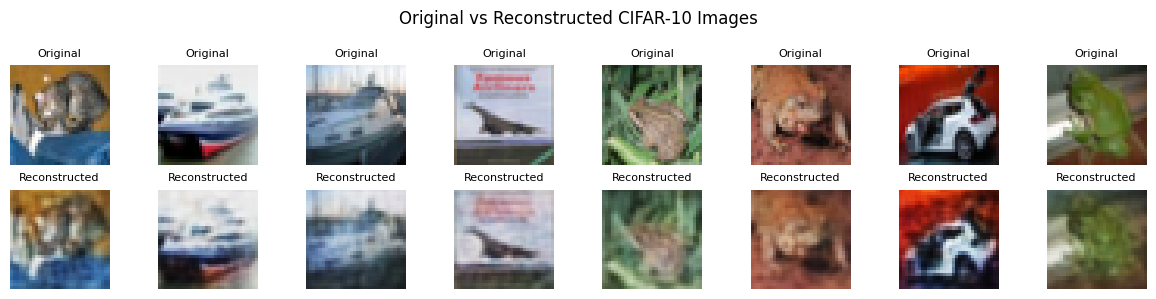

In [7]:
def show_images(original, reconstructed, n=8):
    """
    Shows original and reconstructed images side by side.
    Images come in as flattened tensors with values in [-1, 1].
    """
    fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 3))

    for i in range(n):
        # reshape back to 3x32x32 and move channels to last dim
        orig_img = original[i].reshape(3, 32, 32).permute(1, 2, 0).cpu().numpy()
        recon_img = reconstructed[i].reshape(3, 32, 32).permute(1, 2, 0).cpu().numpy()

        # undo normalization: from [-1,1] back to [0,1]
        orig_img = orig_img * 0.5 + 0.5
        recon_img = recon_img * 0.5 + 0.5

        # clip just in case
        orig_img = np.clip(orig_img, 0, 1)
        recon_img = np.clip(recon_img, 0, 1)

        axes[0, i].imshow(orig_img)
        axes[0, i].set_title('Original', fontsize=8)
        axes[0, i].axis('off')

        axes[1, i].imshow(recon_img)
        axes[1, i].set_title('Reconstructed', fontsize=8)
        axes[1, i].axis('off')

    plt.suptitle('Original vs Reconstructed CIFAR-10 Images', fontsize=12)
    plt.tight_layout()
    plt.show()


# grab a batch of test images
test_images, _ = next(iter(test_loader))
test_flat = test_images.view(test_images.size(0), -1).to(device)

with torch.no_grad():
    _, reconstructed = model(test_flat)

show_images(test_flat, reconstructed, n=8)

## 8. Experiment with Different Sparsity Regularization Values

We try different values of `sparsity_lambda` to see how it affects reconstruction quality. Higher lambda enforces stronger sparsity — the model uses fewer active neurons but may sacrifice reconstruction quality.

In [8]:
lambda_values = [0, 1e-4, 1e-3, 1e-2]
results = {}

for lam in lambda_values:
    print(f"\n--- Training with sparsity_lambda = {lam} ---")

    # fresh model for each experiment
    exp_model = SparseAutoencoder(in_dims=3072, h_dims=1024,
                                  sparsity_lambda=lam, sparsity_target=0.05).to(device)
    exp_optimizer = torch.optim.Adam(exp_model.parameters(), lr=1e-3)

    # train for 10 epochs (shorter run for comparison)
    exp_losses = []
    for epoch in range(10):
        exp_model.train()
        epoch_loss = 0.0
        for images, _ in train_loader:
            images = images.view(images.size(0), -1).to(device)
            exp_optimizer.zero_grad()
            enc, dec = exp_model(images)
            loss = exp_model.loss_function(dec, images, enc)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(exp_model.parameters(), max_norm=1.0)
            exp_optimizer.step()
            epoch_loss += loss.item()
        avg = epoch_loss / len(train_loader)
        exp_losses.append(avg)
        print(f"  Epoch {epoch+1}/10  Loss: {avg:.4f}")

    # evaluate on test set
    exp_model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.view(images.size(0), -1).to(device)
            enc, dec = exp_model(images)
            loss = exp_model.loss_function(dec, images, enc)
            test_loss += loss.item()
    avg_test = test_loss / len(test_loader)
    print(f"  Test Loss: {avg_test:.4f}")

    results[lam] = {
        'model': exp_model,
        'train_losses': exp_losses,
        'test_loss': avg_test
    }


--- Training with sparsity_lambda = 0 ---
  Epoch 1/10  Loss: 0.0483
  Epoch 2/10  Loss: 0.0200
  Epoch 3/10  Loss: 0.0152
  Epoch 4/10  Loss: 0.0130
  Epoch 5/10  Loss: 0.0116
  Epoch 6/10  Loss: 0.0108
  Epoch 7/10  Loss: 0.0100
  Epoch 8/10  Loss: 0.0095
  Epoch 9/10  Loss: 0.0090
  Epoch 10/10  Loss: 0.0088
  Test Loss: 0.0088

--- Training with sparsity_lambda = 0.0001 ---
  Epoch 1/10  Loss: 0.0824
  Epoch 2/10  Loss: 0.0468
  Epoch 3/10  Loss: 0.0372
  Epoch 4/10  Loss: 0.0312
  Epoch 5/10  Loss: 0.0268
  Epoch 6/10  Loss: 0.0235
  Epoch 7/10  Loss: 0.0207
  Epoch 8/10  Loss: 0.0189
  Epoch 9/10  Loss: 0.0175
  Epoch 10/10  Loss: 0.0163
  Test Loss: 0.0164

--- Training with sparsity_lambda = 0.001 ---
  Epoch 1/10  Loss: 0.2297
  Epoch 2/10  Loss: 0.1457
  Epoch 3/10  Loss: 0.1177
  Epoch 4/10  Loss: 0.0954
  Epoch 5/10  Loss: 0.0761
  Epoch 6/10  Loss: 0.0600
  Epoch 7/10  Loss: 0.0486
  Epoch 8/10  Loss: 0.0402
  Epoch 9/10  Loss: 0.0341
  Epoch 10/10  Loss: 0.0287
  Test Lo

### Compare Training Curves

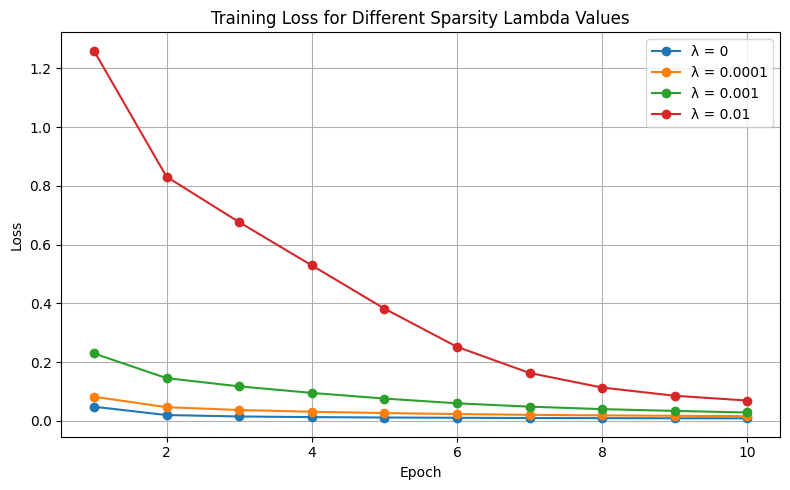

In [9]:
plt.figure(figsize=(8, 5))
for lam, data in results.items():
    plt.plot(range(1, 11), data['train_losses'], marker='o', label=f'λ = {lam}')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss for Different Sparsity Lambda Values')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Compare Test Reconstruction Loss

In [10]:
print("Test Reconstruction Loss Summary:")
print("-" * 40)
for lam, data in results.items():
    print(f"  λ = {lam:<8}  →  Test Loss = {data['test_loss']:.4f}")

Test Reconstruction Loss Summary:
----------------------------------------
  λ = 0         →  Test Loss = 0.0088
  λ = 0.0001    →  Test Loss = 0.0164
  λ = 0.001     →  Test Loss = 0.0278
  λ = 0.01      →  Test Loss = 0.0676


### Visualize Reconstructions for Each Lambda

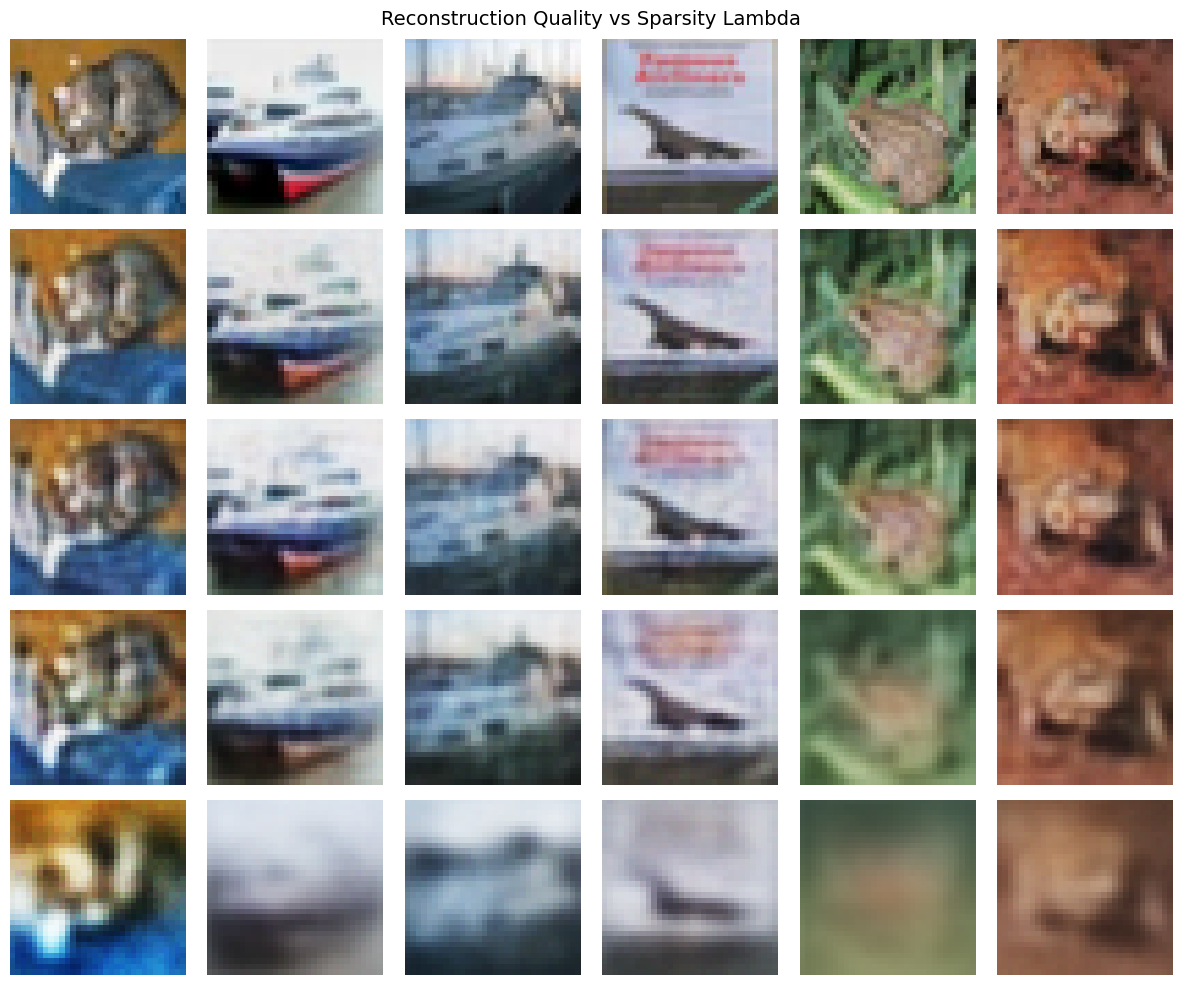

In [11]:
# use the same test batch for fair comparison
sample_images, _ = next(iter(test_loader))
sample_flat = sample_images.view(sample_images.size(0), -1).to(device)

n = 6  # number of images to show
fig, axes = plt.subplots(len(lambda_values) + 1, n, figsize=(n * 2, (len(lambda_values) + 1) * 2))

# first row: original images
for i in range(n):
    img = sample_flat[i].reshape(3, 32, 32).permute(1, 2, 0).cpu().numpy()
    img = img * 0.5 + 0.5
    img = np.clip(img, 0, 1)
    axes[0, i].imshow(img)
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Original', fontsize=10)

# remaining rows: reconstructions for each lambda
for row, lam in enumerate(lambda_values, start=1):
    exp_model = results[lam]['model']
    exp_model.eval()
    with torch.no_grad():
        _, recon = exp_model(sample_flat)

    for i in range(n):
        img = recon[i].reshape(3, 32, 32).permute(1, 2, 0).cpu().numpy()
        img = img * 0.5 + 0.5
        img = np.clip(img, 0, 1)
        axes[row, i].imshow(img)
        axes[row, i].axis('off')
        if i == 0:
            axes[row, i].set_ylabel(f'λ={lam}', fontsize=10)

plt.suptitle('Reconstruction Quality vs Sparsity Lambda', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Observations

- **No sparsity (λ = 0)**: The model is free to use all hidden neurons. It generally gives the best reconstruction quality since there's no constraint on activations.

- **Low sparsity (λ = 1e-4)**: Very slight regularization. Reconstruction quality remains nearly the same, but the model starts learning slightly more selective features.

- **Moderate sparsity (λ = 1e-3)**: A good balance. The model is pushed to learn compact, meaningful features while still producing decent reconstructions.

- **High sparsity (λ = 1e-2)**: Strong constraint. Reconstruction quality drops more noticeably because the model is forced to rely on very few active neurons. However, the learned features tend to be more interpretable and focused.

### Key Takeaway
There is a trade-off between **reconstruction accuracy** and **sparsity**. Higher sparsity leads to more selective and focused feature representations, but at the cost of some reconstruction detail. The right lambda depends on whether the goal is accurate reconstruction or learning meaningful sparse features.